In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

In [2]:
df1 = pd.read_csv("income.csv")
print(df1.info())
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   fnlwgt          48842 non-null  int64
 2   education_num   48842 non-null  int64
 3   capital_gain    48842 non-null  int64
 4   capital_loss    48842 non-null  int64
 5   hours_per_week  48842 non-null  int64
 6   income_level    48842 non-null  int64
dtypes: int64(7)
memory usage: 2.6 MB
None


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_level
0,39,77516,13,2174,0,40,0
1,50,83311,13,0,0,13,0
2,38,215646,9,0,0,40,0
3,53,234721,7,0,0,40,0
4,28,338409,13,0,0,40,0


In [14]:
# Load dataset
df1 = pd.read_csv("income.csv")

# Features and target
X = df1.drop("income_level", axis=1)
y = df1["income_level"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# AdaBoost model with 10 estimators
model_10 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=10,
    random_state=42
)

# Train
model_10.fit(X_train, y_train)

# Predict
y_pred_10 = model_10.predict(X_test)

# Accuracy
acc_10 = accuracy_score(y_test, y_pred_10)
print("Accuracy with 10 estimators:", acc_10)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_10))

Accuracy with 10 estimators: 0.8182004299314157
Confusion Matrix:
 [[6782  632]
 [1144 1211]]


n_estimators = 10, Accuracy = 0.8182004299314157
n_estimators = 20, Accuracy = 0.8244446719213839
n_estimators = 50, Accuracy = 0.8327362063670796
n_estimators = 100, Accuracy = 0.8328385709898659
n_estimators = 150, Accuracy = 0.8329409356126523
n_estimators = 200, Accuracy = 0.8332480294810114

Best number of trees: 200
Best accuracy: 0.8332480294810114


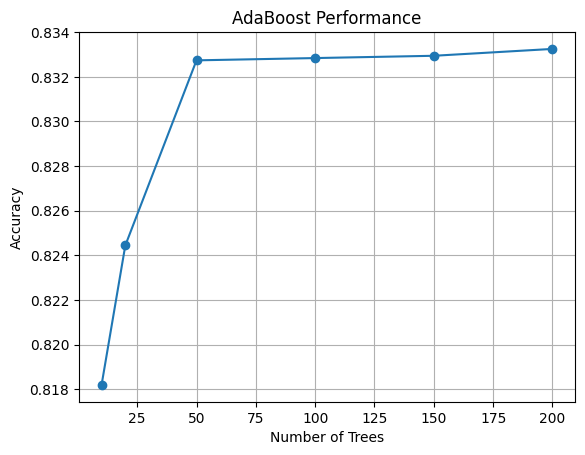

In [7]:
estimators = [10, 20, 50, 100, 150, 200]
accuracies = []

for n in estimators:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"n_estimators = {n}, Accuracy = {acc}")

# Best result
best_index = np.argmax(accuracies)
print("\nBest number of trees:", estimators[best_index])
print("Best accuracy:", accuracies[best_index])

# Plot
plt.plot(estimators, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("AdaBoost Performance")
plt.grid()
plt.show()